In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

##### Load Data

In [74]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "salary"
]

In [75]:
df = pd.read_csv("adult-all.csv", header=None, names=columns, skipinitialspace=True)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##### Exploratory Data Analysis

In [76]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48842 non-null  object
 14  salary          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [77]:
# Shape
df.shape

(48842, 15)

In [78]:
# Unique values
df.nunique()

age                  74
workclass             9
fnlwgt            28523
education            16
education_num        16
marital_status        7
occupation           15
relationship          6
race                  5
sex                   2
capital_gain        123
capital_loss         99
hours_per_week       96
native_country       42
salary                2
dtype: int64

In [79]:
# Missing values count
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
salary            0
dtype: int64

In [80]:
# Salary distribution
df["salary"].value_counts()


salary
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [81]:
df["salary"].value_counts(normalize=True) * 100

salary
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

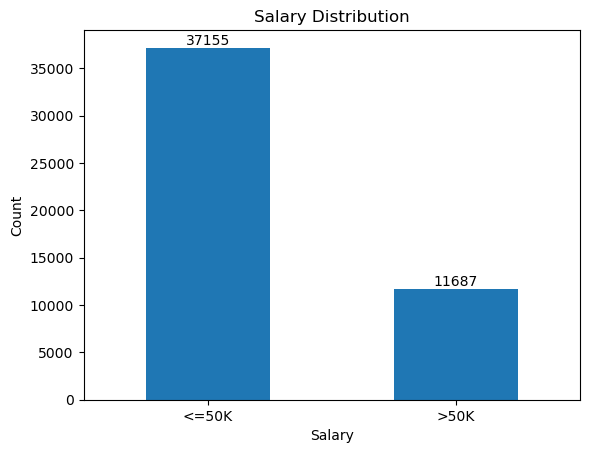

In [82]:
ax = df["salary"].value_counts().plot(kind='bar')

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

# Make x labels horizontal
plt.xticks(rotation=0)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

In [83]:
# Numerical summary
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [84]:
# Categorical feature analysis and data quality check
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))

print("\n===== '?' VALUE CHECK =====")
for col in cat_cols:
    print(f"{col}:", (df[col] == '?').sum())

print("\n===== CROSS-TAB ANALYSIS =====")
for col in cat_cols:
    if col != "salary":
        print(f"\n--- {col} vs salary ---")
        print(pd.crosstab(df[col], df["salary"], normalize='index') * 100)



--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales              

In [85]:
# Grouped numerical analysis
num_cols = df.select_dtypes(include=np.number).columns
print(df.groupby("salary")[num_cols].mean())

              age         fnlwgt  education_num  capital_gain  capital_loss  \
salary                                                                        
<=50K   36.872184  190039.565523       9.598493    147.010308     54.151931   
>50K    44.275178  188470.574570      11.602807   4042.239497    193.528964   

        hours_per_week  
salary                  
<=50K        38.840048  
>50K         45.452896  


##### Data Cleansing

In [86]:
df.replace('?', np.nan, inplace=True)
df = df.dropna()
df = df.drop_duplicates()
df = df.drop(columns=["education"])

##### Encoding

In [87]:
df["salary"] = df["salary"].map({"<=50K": 0, ">50K": 1})
df = pd.get_dummies(df, drop_first=True)

##### Split Data

In [88]:
X = df.drop("salary", axis=1)
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Feature Scaling

In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Find Optimal K

In [90]:
k_values = range(1, 21)
test_accuracies = []
train_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    test_pred = knn.predict(X_test_scaled)
    train_pred = knn.predict(X_train_scaled)
    
    test_acc = accuracy_score(y_test, test_pred)
    train_acc = accuracy_score(y_train, train_pred)
    
    test_accuracies.append(test_acc)
    train_accuracies.append(train_acc)
    
    print(f"K={k}, Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

K=1, Train Acc=0.9999, Test Acc=0.7900
K=2, Train Acc=0.8943, Test Acc=0.8051
K=3, Train Acc=0.8937, Test Acc=0.8134
K=4, Train Acc=0.8726, Test Acc=0.8180
K=5, Train Acc=0.8736, Test Acc=0.8195
K=6, Train Acc=0.8651, Test Acc=0.8203
K=7, Train Acc=0.8646, Test Acc=0.8197
K=8, Train Acc=0.8591, Test Acc=0.8208
K=9, Train Acc=0.8597, Test Acc=0.8208
K=10, Train Acc=0.8564, Test Acc=0.8210
K=11, Train Acc=0.8566, Test Acc=0.8218
K=12, Train Acc=0.8527, Test Acc=0.8234
K=13, Train Acc=0.8529, Test Acc=0.8251
K=14, Train Acc=0.8501, Test Acc=0.8246
K=15, Train Acc=0.8510, Test Acc=0.8253
K=16, Train Acc=0.8494, Test Acc=0.8258
K=17, Train Acc=0.8487, Test Acc=0.8253
K=18, Train Acc=0.8467, Test Acc=0.8252
K=19, Train Acc=0.8467, Test Acc=0.8255
K=20, Train Acc=0.8456, Test Acc=0.8251


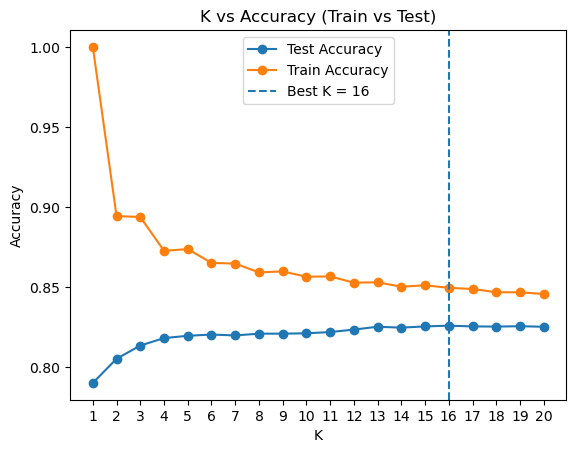

In [98]:
plt.figure()

plt.plot(k_values, test_accuracies, marker='o', label="Test Accuracy")
plt.plot(k_values, train_accuracies, marker='o', label="Train Accuracy")

# Highlight best K
plt.axvline(x=best_k, linestyle='--', label=f"Best K = {best_k}")

plt.xticks(range(1, 21))
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy (Train vs Test)")
plt.legend()

plt.show()

In [92]:
# best K
best_k = k_values[np.argmax(test_accuracies)]
print("\nBest K:", best_k)


Best K: 16


##### Final Model

In [93]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

##### Evaluation

In [94]:
print(f"Final Accuracy:{accuracy_score(y_test, y_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# ROC-AUC
y_probs = knn_final.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs)}")

Final Accuracy:0.8257885998893193

Confusion Matrix:
[[6311  484]
 [1090 1150]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      6795
           1       0.70      0.51      0.59      2240

    accuracy                           0.83      9035
   macro avg       0.78      0.72      0.74      9035
weighted avg       0.82      0.83      0.82      9035

ROC-AUC Score: 0.8690197295805739


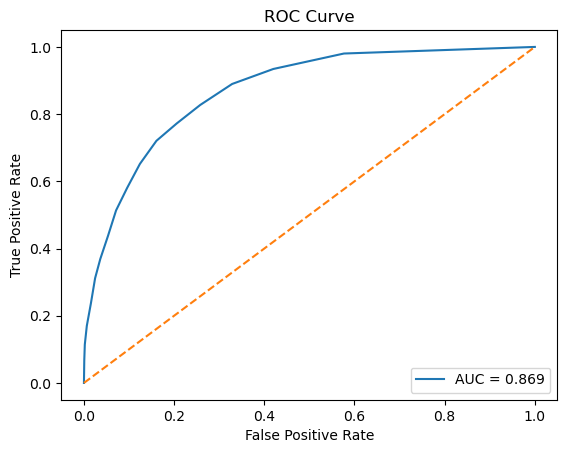

In [95]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

##### Feature Importance

In [96]:
corr = df.corr(numeric_only=True)["salary"].sort_values(ascending=False)

print("\nTop Features (Positive Influence on High Income):\n")
print(corr.head(10))
print("\n\nTop Features (Negative Influence on High Income):\n")
print(corr.tail(10))



Top Features (Positive Influence on High Income):

salary                               1.000000
marital_status_Married-civ-spouse    0.446013
education_num                        0.332981
age                                  0.236839
hours_per_week                       0.227146
capital_gain                         0.221071
sex_Male                             0.215741
occupation_Exec-managerial           0.209060
occupation_Prof-specialty            0.183345
capital_loss                         0.148679
Name: salary, dtype: float64


Top Features (Negative Influence on High Income):

occupation_Machine-op-inspct   -0.076843
relationship_Other-relative    -0.085686
race_Black                     -0.090501
occupation_Handlers-cleaners   -0.091749
workclass_Private              -0.116674
relationship_Unmarried         -0.147395
occupation_Other-service       -0.165518
relationship_Not-in-family     -0.195294
relationship_Own-child         -0.222633
marital_status_Never-married   -0.319

##### Save Clean Data

In [97]:
df.to_csv("cleaned_adult-all.csv", index=False)